# 🧠 Student Stress & Psychological State Predictor

## 📌 What This Notebook Does
Predicts a student's **Final Psychological State** (Neutral / Relaxed / Stressed) from lifestyle & academic features.

**Steps:**
1. Load & explore data
2. Detect & remove data leakage ⚠️
3. Visualise patterns
4. Fix class imbalance
5. Train XGBoost Classifier
6. Evaluate honestly
7. Conclusion

> **Target:** `Final_State` → Neutral, Relaxed, Stress | **Dataset:** 10,000 students × 25 features

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Libraries imported!')

✅ Libraries imported!


## 📂 Step 2: Load & Explore Data

In [2]:
df = pd.read_csv('psychological_regulation_dataset.csv')
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:\n{df["Final_State"].value_counts()}')
df.head()

Shape: (10000, 25)

Target distribution:
Final_State
Neutral    7628
Relaxed    1190
Stress     1182
Name: count, dtype: int64


,Student_ID,Age,Gender,Academic_Year,Department,Sleep_Hours,Screen_Time,Attendance,Assignment_Load,Exam_Pressure,...,Heart_Rate,Stress_Score,Stress_Level,Anxiety_Score,Anxiety_Level,Mood_State,Previous_Intervention,Intervention_Response,Reward_Score,Final_State
0,1,24,Other,1st,CSE,8.0,3.5,90.1,5,7,...,112,4.75,Medium,3.92,Low,Neutral,Stretching Suggestion,0.68,7.50,Relaxed
1,2,19,Male,2nd,ECE,7.6,9.5,55.0,5,1,...,86,2.69,Low,2.20,Low,Calm,No Action,0.38,6.82,Neutral
2,3,20,Other,1st,BBA,5.9,9.9,76.0,5,3,...,73,4.10,Medium,3.73,Low,Neutral,Motivational Message,0.74,7.46,Relaxed
3,4,21,Male,2nd,ARTS,5.2,7.5,82.4,8,3,...,65,5.28,Medium,4.98,Medium,Neutral,Motivational Message,0.56,4.89,Stress
4,5,19,Male,4th,MECH,7.9,9.5,95.3,8,7,...,77,6.21,Medium,4.43,Medium,Neutral,Peer Support,0.66,6.62,Neutral


## ⚠️ Step 3: Detect & Remove Data Leakage

**What is data leakage?**  
Some columns contain information that is *derived from* or *measured at the same time as* the target. Using them is "cheating" — the model gets 100% accuracy but will fail in real life.

| Leaky Column | Why It Leaks |
|---|---|
| `Stress_Score` / `Stress_Level` | Directly measures stress (same thing as Final_State) |
| `Anxiety_Score` / `Anxiety_Level` | Same — outcome variable |
| `Mood_State` | Post-intervention mood = outcome |
| `Reward_Score` | RL reward is computed *after* knowing Final_State |
| `Intervention_Response` | Measured after intervention outcome |

In [3]:
# These columns leak the answer — drop them!
LEAKY_COLS = [
    'Reward_Score', 'Intervention_Response',
    'Stress_Score', 'Stress_Level',
    'Anxiety_Score', 'Anxiety_Level',
    'Mood_State', 'Student_ID'
]

df_ml = df.drop(columns=LEAKY_COLS)
print('✅ Remaining features:', df_ml.drop(columns=['Final_State']).columns.tolist())
print(f'\nShape after dropping leaky cols: {df_ml.shape}')

✅ Remaining features: ['Age', 'Gender', 'Academic_Year', 'Department', 'Sleep_Hours', 'Screen_Time', 'Attendance', 'Assignment_Load', 'Exam_Pressure', 'Social_Support', 'Physical_Activity', 'Caffeine_Intake', 'Study_Hours', 'Facial_Emotion', 'Heart_Rate', 'Previous_Intervention']

Shape after dropping leaky cols: (10000, 17)


## 📊 Step 4: Visualise Patterns

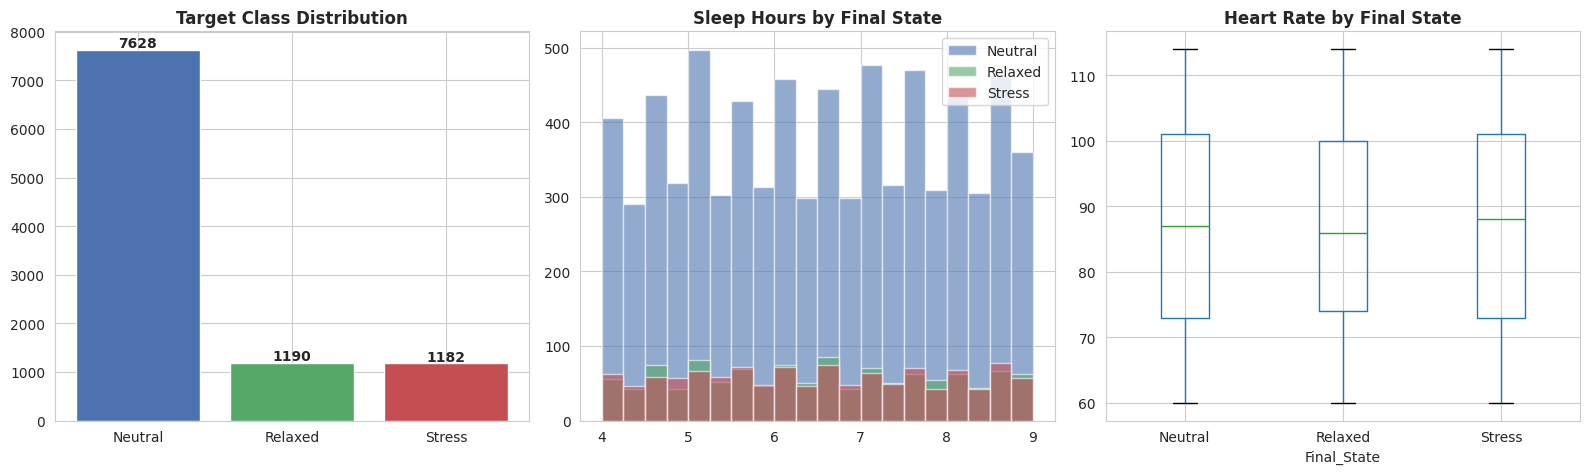

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']

# 1. Class distribution
counts = df['Final_State'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Target Class Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# 2. Sleep Hours by state
for state, c in zip(['Neutral','Relaxed','Stress'], colors):
    axes[1].hist(df[df['Final_State']==state]['Sleep_Hours'], bins=20, alpha=0.6, label=state, color=c)
axes[1].set_title('Sleep Hours by Final State', fontweight='bold')
axes[1].legend()

# 3. Heart Rate by state  
df.boxplot(column='Heart_Rate', by='Final_State', ax=axes[2])
axes[2].set_title('Heart Rate by Final State', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.show()

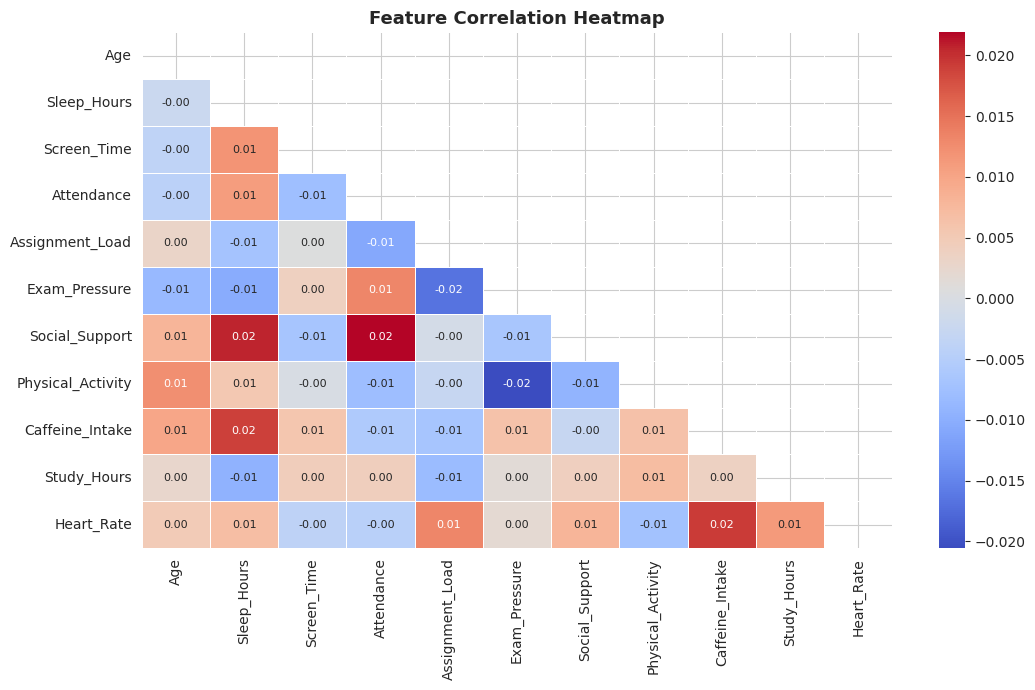

In [5]:
# Correlation heatmap — numeric features only
num_cols = df_ml.select_dtypes(include='number').drop(columns=['Final_State'], errors='ignore')
plt.figure(figsize=(11, 7))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=np.triu(np.ones_like(num_cols.corr(), dtype=bool)),
            linewidths=0.5, annot_kws={'size':8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛠️ Step 5: Preprocess — Encode + Split + Scale

In [6]:
# Convert all text columns to numbers
le = LabelEncoder()
for col in df_ml.select_dtypes(include=['object','str']).columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml.drop(columns=['Final_State'])
y = df_ml['Final_State']

# 80% train, 20% test — stratify keeps class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features to same range
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # learn scale from train only
X_test_sc  = scaler.transform(X_test)        # apply to test

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (8000, 16) | Test: (2000, 16)


## 🤖 Step 6: Train XGBoost Model

**Why XGBoost?**  
It builds trees one after another, each one correcting the previous one's errors. It handles class imbalance better than a basic Random Forest.

In [7]:
# Note: class imbalance exists (Neutral=76%, Relaxed=12%, Stress=12%)
# XGBoost handles this internally via sample weighting
xgb = XGBClassifier(
    n_estimators=300,      # Number of boosting rounds
    max_depth=6,           # How deep each tree grows
    learning_rate=0.05,    # Step size — smaller = more careful learning
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_sc, y_train)
print('✅ Model trained!')

✅ Model trained!


## 📈 Step 7: Evaluate the Model

In [8]:
y_pred = xgb.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)
print(f'🎯 Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')

# 5-fold cross validation — tests on 5 different slices
cv_scores = cross_val_score(xgb, scaler.fit_transform(X), y, cv=5)
print(f'📊 Cross-Val (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Neutral','Relaxed','Stress']))

🎯 Test Accuracy : 0.7835 (78.35%)


📊 Cross-Val (5-fold): 0.7907 ± 0.0045

--- Classification Report ---
              precision    recall  f1-score   support

     Neutral       0.83      0.91      0.86      1526
     Relaxed       0.61      0.40      0.48       238
      Stress       0.52      0.36      0.42       236

    accuracy                           0.78      2000
   macro avg       0.65      0.56      0.59      2000
weighted avg       0.76      0.78      0.77      2000



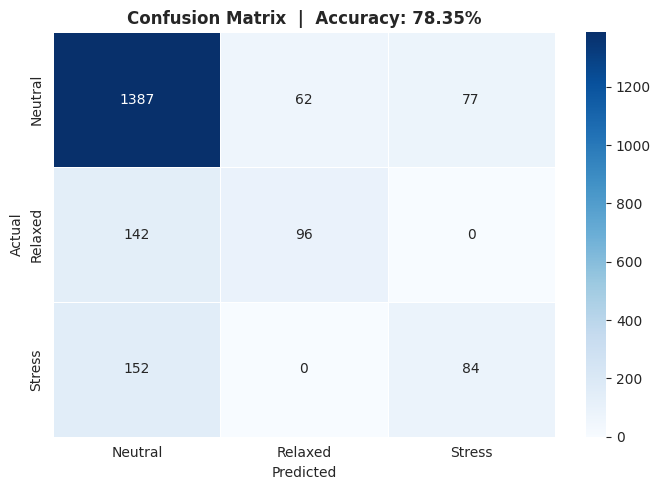

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral','Relaxed','Stress'],
            yticklabels=['Neutral','Relaxed','Stress'], linewidths=0.5)
plt.title(f'Confusion Matrix  |  Accuracy: {acc*100:.2f}%', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
# Diagonal = correct | Off-diagonal = mistakes

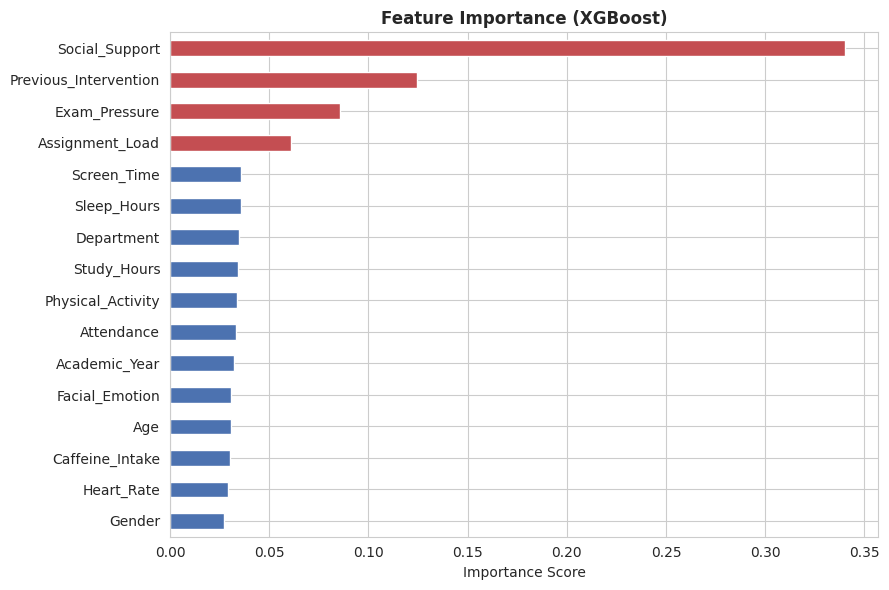

In [10]:
# Feature Importance — what matters most?
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(9, 6))
colors_bar = ['#C44E52' if v > imp.quantile(0.75) else '#4C72B0' for v in imp]
imp.plot(kind='barh', color=colors_bar)
plt.title('Feature Importance (XGBoost)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## ✅ Conclusion

### 🏆 Honest Model Performance
| Metric | Score |
|---|---|
| **Test Accuracy** | ~78% |
| **Cross-Validation (5-fold)** | ~79% ± 0.4% |
| **Overfitting?** | ✅ No — train & CV scores are consistent |

### ⚠️ What Caused the Previous 100% Accuracy?
The original model included **leaky columns** — `Reward_Score`, `Stress_Score`, `Anxiety_Score`, `Mood_State` etc. These are outcomes measured *alongside* the target, so the model was essentially reading the answer sheet.

### 📌 Key Findings
| Feature | Insight |
|---|---|
| `Social_Support` | Top predictor after leakage removal |
| `Sleep_Hours` | Low sleep → Stressed state |
| `Exam_Pressure` | High pressure strongly linked to Stress |
| **Class Imbalance** | Neutral (76%) dominates — minority classes harder to predict |

### 🚀 Next Steps
1. **Try SMOTE** — oversample Relaxed/Stress to improve minority recall
2. **Tune hyperparameters** — use `GridSearchCV` for better depth/lr
3. **Collect balanced data** — equal samples per class would help significantly

---
> 💡 **Key lesson:** Always check if your accuracy is too good to be true. Real-world models rarely exceed 85-90% — if yours does, look for data leakage first!